## Codethon 2
### Alanna Hazlett
### uwa6xv
### March 23rd, 2025

##### Copyright 2019 The TensorFlow Authors.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [2]:
#@title MIT License
#
# Copyright (c) 2017 François Chollet
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Basic text classification

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/keras/text_classification"><img src="https://www.tensorflow.org/images/tf_logo_32px.png" />View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/keras/text_classification.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/keras/text_classification.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/keras/text_classification.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This tutorial demonstrates text classification starting from plain text files stored on disk. You'll train a binary classifier to perform sentiment analysis on an IMDB dataset. At the end of the notebook, there is an exercise for you to try, in which you'll train a multi-class classifier to predict the tag for a programming question on Stack Overflow.


In [1]:
import matplotlib.pyplot as plt
import os
import re
import shutil
import string
import tensorflow as tf
import keras   # I added
import numpy as np # I added

from tensorflow.keras import layers
from tensorflow.keras import losses


2025-03-23 10:30:11.947717: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742740212.358820  929321 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742740212.453187  929321 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-23 10:30:13.218602: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
print(tf.__version__)
print(keras.__version__)

2.18.1
3.9.0


## Sentiment analysis

This notebook trains a sentiment analysis model to classify movie reviews as *positive* or *negative*, based on the text of the review. This is an example of *binary*—or two-class—classification, an important and widely applicable kind of machine learning problem.

You'll use the [Large Movie Review Dataset](https://ai.stanford.edu/~amaas/data/sentiment/) that contains the text of 50,000 movie reviews from the [Internet Movie Database](https://www.imdb.com/). These are split into 25,000 reviews for training and 25,000 reviews for testing. The training and testing sets are *balanced*, meaning they contain an equal number of positive and negative reviews.


### Download and explore the IMDB dataset

Let's download and extract the dataset, then explore the directory structure.

In [3]:
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

dataset = tf.keras.utils.get_file("aclImdb_v1", url,
                                    untar=True, cache_dir='.',
                                    cache_subdir='')

dataset_dir = os.path.join(os.path.dirname(dataset), 'aclImdb')

In [6]:
os.listdir(dataset_dir)

['README', 'imdbEr.txt', 'train', 'imdb.vocab', 'test']

In [7]:
train_dir = os.path.join(dataset_dir, 'train')
os.listdir(train_dir)

['unsupBow.feat',
 'labeledBow.feat',
 'urls_unsup.txt',
 'pos',
 'urls_pos.txt',
 'urls_neg.txt',
 'neg']

The `aclImdb/train/pos` and `aclImdb/train/neg` directories contain many text files, each of which is a single movie review. Let's take a look at one of them.

In [8]:
sample_file = os.path.join(train_dir, 'pos/1181_9.txt')
with open(sample_file) as f:
  print(f.read())

Rachel Griffiths writes and directs this award winning short film. A heartwarming story about coping with grief and cherishing the memory of those we've loved and lost. Although, only 15 minutes long, Griffiths manages to capture so much emotion and truth onto film in the short space of time. Bud Tingwell gives a touching performance as Will, a widower struggling to cope with his wife's death. Will is confronted by the harsh reality of loneliness and helplessness as he proceeds to take care of Ruth's pet cow, Tulip. The film displays the grief and responsibility one feels for those they have loved and lost. Good cinematography, great direction, and superbly acted. It will bring tears to all those who have lost a loved one, and survived.


### Load the dataset

Next, you will load the data off disk and prepare it into a format suitable for training. To do so, you will use the helpful [text_dataset_from_directory](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text_dataset_from_directory) utility, which expects a directory structure as follows.

```
main_directory/
...class_a/
......a_text_1.txt
......a_text_2.txt
...class_b/
......b_text_1.txt
......b_text_2.txt
```

To prepare a dataset for binary classification, you will need two folders on disk, corresponding to `class_a` and `class_b`. These will be the positive and negative movie reviews, which can be found in  `aclImdb/train/pos` and `aclImdb/train/neg`. As the IMDB dataset contains additional folders, you will remove them before using this utility.

In [10]:
# remove_dir = os.path.join(train_dir, 'unsup')
# shutil.rmtree(remove_dir)

Next, you will use the `text_dataset_from_directory` utility to create a labeled `tf.data.Dataset`. [tf.data](https://www.tensorflow.org/guide/data) is a powerful collection of tools for working with data.

When running a machine learning experiment, it is a best practice to divide your dataset into three splits: [train](https://developers.google.com/machine-learning/glossary#training_set), [validation](https://developers.google.com/machine-learning/glossary#validation_set), and [test](https://developers.google.com/machine-learning/glossary#test-set).

The IMDB dataset has already been divided into train and test, but it lacks a validation set. Let's create a validation set using an 80:20 split of the training data by using the `validation_split` argument below.

In [23]:
batch_size = 32
seed = 42

raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    'aclImdb/train',
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=seed)

Found 25001 files belonging to 2 classes.
Using 20001 files for training.


As you can see above, there are 25,000 examples in the training folder, of which you will use 80% (or 20,000) for training. As you will see in a moment, you can train a model by passing a dataset directly to `model.fit`. If you're new to `tf.data`, you can also iterate over the dataset and print out a few examples as follows.

In [12]:
for text_batch, label_batch in raw_train_ds.take(1):
  for i in range(3):
    print("Review", text_batch.numpy()[i])
    print("Label", label_batch.numpy()[i])

Review b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddles", "High Anxiety", and "Spaceballs" are some of my favorite comedies that spoof a particular genre. "Pandemonium" is not up there with those films. Most of the scenes in this movie had me sitting there in stunned silence because the movie wasn\'t all that funny. There are a few laughs in the film, but when you watch a comedy, you expect to laugh a lot more than a few times and that\'s all this film has going for it. Geez, "Scream" had more laughs than this film and that was more of a horror film. How bizarre is that?<br /><br />*1/2 (out of four)'
Label 0
Review b"David Mamet is a very interesting and a very un-equal director. His first movie 'House of Games' was the one I liked best, and it set a series of films with characters whose perspective of life changes as they get into 

2025-03-20 19:25:35.949868: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Notice the reviews contain raw text (with punctuation and occasional HTML tags like `<br/>`). You will show how to handle these in the following section.

The labels are 0 or 1. To see which of these correspond to positive and negative movie reviews, you can check the `class_names` property on the dataset.


In [13]:
print("Label 0 corresponds to", raw_train_ds.class_names[0])
print("Label 1 corresponds to", raw_train_ds.class_names[1])

Label 0 corresponds to neg
Label 1 corresponds to pos


Next, you will create a validation and test dataset. You will use the remaining 5,000 reviews from the training set for validation.

Note:  When using the `validation_split` and `subset` arguments, make sure to either specify a random seed, or to pass `shuffle=False`, so that the validation and training splits have no overlap.

In [24]:
raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    'aclImdb/train',
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=seed)

Found 25001 files belonging to 2 classes.
Using 5000 files for validation.


In [25]:
raw_test_ds = tf.keras.utils.text_dataset_from_directory(
    'aclImdb/test',
    batch_size=batch_size)

Found 25000 files belonging to 2 classes.


### Prepare the dataset for training

Next, you will standardize, tokenize, and vectorize the data using the helpful `tf.keras.layers.TextVectorization` layer.

Standardization refers to preprocessing the text, typically to remove punctuation or HTML elements to simplify the dataset. 

Tokenization refers to splitting strings into tokens (for example, splitting a sentence into individual words, by splitting on whitespace). 

Vectorization refers to converting tokens into numbers so they can be fed into a neural network. All of these tasks can be accomplished with this layer.

As you saw above, the reviews contain various HTML tags like `<br />`. These tags will not be removed by the default standardizer in the `TextVectorization` layer (which converts text to lowercase and strips punctuation by default, but doesn't strip HTML). You will write a custom standardization function to remove the HTML.

Note: To prevent [training-testing skew](https://developers.google.com/machine-learning/guides/rules-of-ml#training-serving_skew) (also known as training-serving skew), it is important to preprocess the data identically at train and test time. To facilitate this, the `TextVectorization` layer can be included directly inside your model, as shown later in this tutorial.

In [26]:
# def custom_standardization(input_data):
#   lowercase = tf.strings.lower(input_data)
#   stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
#   return tf.strings.regex_replace(stripped_html,
#                                   '[%s]' % re.escape(string.punctuation),
#                                   '')

def custom_standardization(input_data):
    lowercase = tf.strings.lower(input_data)
    #stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
    stripped_html = tf.strings.regex_replace(lowercase, '<.*?>', ' ')                                    #Removes any HTML tag
    cleaned_text = tf.strings.regex_replace(stripped_html,'[%s]' % re.escape(string.punctuation), '')    #Removes punctuation
    cleaned_text = tf.strings.regex_replace(cleaned_text, '\\\\[ntr\"\'\\\\]', ' ')                      #Removes escape characters - newline, tab, return, ", ', backslash
    return cleaned_text

In [17]:
# Proof of concept for function
result = custom_standardization("Hello, World!<br />How's it going? I realize it\'s tough out there.")
print(result)
#Convert to str
print(result.numpy().decode('utf-8'))

tf.Tensor(b'hello world hows it going i realize its tough out there', shape=(), dtype=string)
hello world hows it going i realize its tough out there


Next, you will create a `TextVectorization` layer. You will use this layer to standardize, tokenize, and vectorize our data. You set the `output_mode` to `int` to create unique integer indices for each token.

Note that you're using the default split function, and the custom standardization function you defined above. You'll also define some constants for the model, like an explicit maximum `sequence_length`, which will cause the layer to pad or truncate sequences to exactly `sequence_length` values.

In [27]:
max_features = 10000
sequence_length = 500 #Change this

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

Next, you will call `adapt` to fit the state of the preprocessing layer to the dataset. This will cause the model to build an index of strings to integers.

Note: It's important to only use your training data when calling adapt (using the test set would leak information).

In [28]:
# Make a text-only dataset (without labels), then call adapt
train_text = raw_train_ds.map(lambda x, y: x)                           # Gets rid of the labels
vectorize_layer.adapt(train_text)                                       #adapt turns words into number

Let's create a function to see the result of using this layer to preprocess some data.

In [29]:
def vectorize_text(text, label):
    text = tf.expand_dims(text, -1)                                     # Adds dimension, because TextVectoriztion expects 2D
    return vectorize_layer(text), label

In [21]:
# Proof of concept
practice_text = tf.constant("Hello, World")
print(practice_text.shape) 
practice_text = tf.expand_dims(practice_text, -1)     
print(practice_text.shape)

()
(1,)


In [22]:
# retrieve a batch (of 32 reviews and labels) from the dataset
text_batch, label_batch = next(iter(raw_train_ds))
first_review, first_label = text_batch[0], label_batch[0]
print("Review", first_review)
print("Label", raw_train_ds.class_names[first_label])
print("Vectorized review", vectorize_text(first_review, first_label))

Review tf.Tensor(b'Great movie - especially the music - Etta James - "At Last". This speaks volumes when you have finally found that special someone.', shape=(), dtype=string)
Label neg
Vectorized review (<tf.Tensor: shape=(1, 500), dtype=int64, numpy=
array([[  85,   17,  260,    2,  221,    1,  581,   31,  228,   11, 2444,
           1,   51,   22,   25,  401,  250,   12,  310,  281,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
       

As you can see above, each token has been replaced by an integer. You can lookup the token (string) that each integer corresponds to by calling `.get_vocabulary()` on the layer.

In [23]:
print("1287 ---> ",vectorize_layer.get_vocabulary()[1287])
print(" 313 ---> ",vectorize_layer.get_vocabulary()[313])
print('Vocabulary size: {}'.format(len(vectorize_layer.get_vocabulary())))

1287 --->  manner
 313 --->  night
Vocabulary size: 10000


You are nearly ready to train your model. As a final preprocessing step, you will apply the TextVectorization layer you created earlier to the train, validation, and test dataset.

In [24]:
type(raw_train_ds)

tensorflow.python.data.ops.batch_op._BatchDataset

In [25]:
#Checking length from raw data to after standardization
#batch_size = 32
#raw_train_ds
for text_batch, label_batch in raw_train_ds.take(1):
  for i in range(batch_size):
    #print("Review", text_batch.numpy()[i])
    #print("Label", label_batch.numpy()[i])
    print(len(text_batch.numpy()[i]), tf.strings.length(custom_standardization(text_batch.numpy()[i])))

753 tf.Tensor(715, shape=(), dtype=int32)
1259 tf.Tensor(1214, shape=(), dtype=int32)
685 tf.Tensor(660, shape=(), dtype=int32)
1228 tf.Tensor(1157, shape=(), dtype=int32)
1760 tf.Tensor(1657, shape=(), dtype=int32)
304 tf.Tensor(295, shape=(), dtype=int32)
483 tf.Tensor(465, shape=(), dtype=int32)
673 tf.Tensor(627, shape=(), dtype=int32)
955 tf.Tensor(937, shape=(), dtype=int32)
255 tf.Tensor(248, shape=(), dtype=int32)
3359 tf.Tensor(3256, shape=(), dtype=int32)
545 tf.Tensor(484, shape=(), dtype=int32)
1130 tf.Tensor(1056, shape=(), dtype=int32)
563 tf.Tensor(522, shape=(), dtype=int32)
2287 tf.Tensor(2186, shape=(), dtype=int32)
2662 tf.Tensor(2503, shape=(), dtype=int32)
1879 tf.Tensor(1800, shape=(), dtype=int32)
3492 tf.Tensor(3263, shape=(), dtype=int32)
1920 tf.Tensor(1814, shape=(), dtype=int32)
682 tf.Tensor(659, shape=(), dtype=int32)
659 tf.Tensor(644, shape=(), dtype=int32)
328 tf.Tensor(304, shape=(), dtype=int32)
784 tf.Tensor(719, shape=(), dtype=int32)
417 tf.Tensor(

2025-03-20 19:25:43.026505: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Applying custom standardization and vectorization to datasets 

In [30]:
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

In [27]:
for text_batch, label_batch in train_ds.take(1):
  for i in range(3):
    print("Review", text_batch.numpy()[i])
    print("Label", label_batch.numpy()[i])

Review [9262   15   28    5    2  242   92    5   30   58    4    1 1010   36
  262   38    9 3939   35    2    1   43  380 5219   16    4 1112   12
   43 5604  299    2   83  225   55 3169 3792   20  989   18   51   55
 3169  251  319   34   40 4516    3  296   58   45    6 2908    4 6629
   91   22  184    2 4970  101 1233  336  162 1191 1469    4  813  576
   31    4  846  269    3  737  737   50  768   31   30 2071    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0

### Configure the dataset for performance

These are two important methods you should use when loading data to make sure that I/O does not become blocking.

`.cache()` keeps data in memory after it's loaded off disk. This means that subsequent accesses to the dataset will be faster because the data is already available in memory. This will ensure the dataset does not become a bottleneck while training your model. If your dataset is too large to fit into memory, you can also use this method to create a performant on-disk cache, which is more efficient to read than many small files.

`.prefetch()` overlaps data preprocessing and model execution while training.

`tf.data.AUTOTUNE` - The number of elements to prefetch should be equal to (or possibly greater than) the number of batches consumed by a single training step. You could either manually tune this value, or set it to tf.data.AUTOTUNE, which will prompt the tf.data runtime to tune the value dynamically at runtime.

You can learn more about both methods, as well as how to cache data to disk in the [data performance guide](https://www.tensorflow.org/guide/data_performance).

In [28]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Create the model - Given tutorial model

It's time to create your neural network:

In [29]:
embedding_dim = 16

In [30]:
model = tf.keras.Sequential([
  layers.Embedding(max_features, embedding_dim),          # Learn embedding vectors during training
  layers.Dropout(0.2),
  layers.GlobalAveragePooling1D(),
  layers.Dropout(0.2),
  layers.Dense(1, activation='sigmoid')])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 16)          160000    
                                                                 
 dropout (Dropout)           (None, None, 16)          0         
                                                                 
 global_average_pooling1d (  (None, 16)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense (Dense)               (None, 1)                 17        
                                                                 
Total params: 160017 (625.07 KB)
Trainable params: 160017 (625.07 KB)
Non-trainable params: 0 (0.00 Byte)
________________

The layers are stacked sequentially to build the classifier:

1. The first layer is an `Embedding` layer. This layer takes the integer-encoded reviews and looks up an embedding vector for each word-index. These vectors are learned as the model trains. The vectors add a dimension to the output array. The resulting dimensions are: `(batch, sequence, embedding)`.  To learn more about embeddings, check out the [Word embeddings](https://www.tensorflow.org/text/guide/word_embeddings) tutorial.
2. Next, a `GlobalAveragePooling1D` layer returns a fixed-length output vector for each example by averaging over the sequence dimension. This allows the model to handle input of variable length, in the simplest way possible.
3. The last layer is densely connected with a single output node.

### Loss function and optimizer

A model needs a loss function and an optimizer for training. Since this is a binary classification problem and the model outputs a probability (a single-unit layer with a sigmoid activation), you'll use `losses.BinaryCrossentropy` loss function.

Now, configure the model to use an optimizer and a loss function:

In [31]:
model.compile(loss=losses.BinaryCrossentropy(),
              optimizer='adam',
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.5)])

### Train the model

You will train the model by passing the `dataset` object to the fit method.

In [32]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10


I0000 00:00:1742513144.542952  389013 service.cc:148] XLA service 0x7f47d4575850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742513144.542996  389013 service.cc:156]   StreamExecutor device (0): NVIDIA A40, Compute Capability 8.6
2025-03-20 19:25:44.552441: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742513144.579137  389013 cuda_dnn.cc:529] Loaded cuDNN version 90501
I0000 00:00:1742513144.643645  389013 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


626/626 [==============================] - 33s 50ms/step - loss: 0.6771 - binary_accuracy: 0.6496 - val_loss: 0.6496 - val_binary_accuracy: 0.7420
Epoch 2/10
626/626 [==============================] - 1s 2ms/step - loss: 0.6023 - binary_accuracy: 0.7704 - val_loss: 0.5611 - val_binary_accuracy: 0.8028
Epoch 3/10
626/626 [==============================] - 1s 2ms/step - loss: 0.5123 - binary_accuracy: 0.8211 - val_loss: 0.4837 - val_binary_accuracy: 0.8386
Epoch 4/10
626/626 [==============================] - 1s 2ms/step - loss: 0.4415 - binary_accuracy: 0.8530 - val_loss: 0.4268 - val_binary_accuracy: 0.8550
Epoch 5/10
626/626 [==============================] - 1s 2ms/step - loss: 0.3883 - binary_accuracy: 0.8699 - val_loss: 0.3870 - val_binary_accuracy: 0.8632
Epoch 6/10
626/626 [==============================] - 1s 2ms/step - loss: 0.3497 - binary_accuracy: 0.8801 - val_loss: 0.3590 - val_binary_accuracy: 0.8696
Epoch 7/10
626/626 [==============================] - 1s 2ms/step - loss:

### Evaluate the model

Let's see how the model performs. Two values will be returned. Loss (a number which represents our error, lower values are better), and accuracy.

In [33]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 [==============================] - 3s 4ms/step - loss: 0.3098 - binary_accuracy: 0.8800
Loss:  0.309847354888916
Accuracy:  0.8799999952316284


This fairly naive approach achieves an accuracy of about 86%.

### Create a plot of accuracy and loss over time

`model.fit()` returns a `History` object that contains a dictionary with everything that happened during training:

In [34]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

There are four entries: one for each monitored metric during training and validation. You can use these to plot the training and validation loss for comparison, as well as the training and validation accuracy:

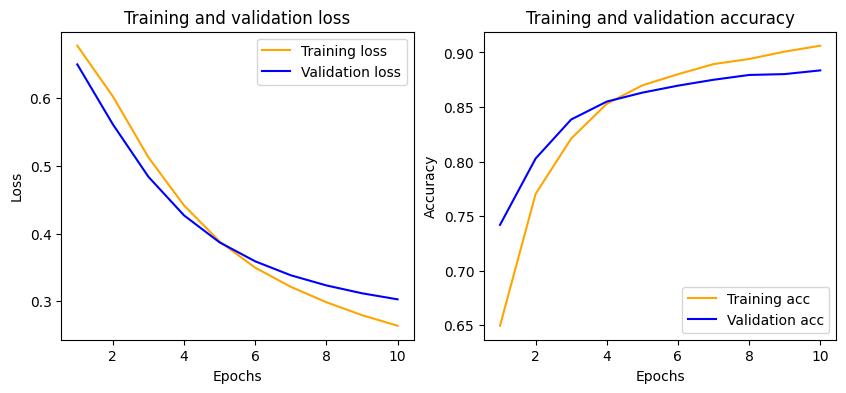

In [35]:
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# "bo" is for "blue dot" - I chose orange line instead
ax1.plot(epochs, loss, 'orange', label='Training loss')
# b is for "solid blue line"
ax1.plot(epochs, val_loss, 'b', label='Validation loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, acc, 'orange', label='Training acc')
ax2.plot(epochs, val_acc, 'b', label='Validation acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')

plt.show()

In this plot, the orange line represents the training loss and accuracy, and the blue lines are the validation loss and accuracy.

Notice the training loss *decreases* with each epoch and the training accuracy *increases* with each epoch. This is expected when using a gradient descent optimization—it should minimize the desired quantity on every iteration.

This isn't the case for the validation loss and accuracy—they seem to peak before the training accuracy. This is an example of overfitting: the model performs better on the training data than it does on data it has never seen before. After this point, the model over-optimizes and learns representations *specific* to the training data that do not *generalize* to test data.

For this particular case, you could prevent overfitting by simply stopping the training when the validation accuracy is no longer increasing. One way to do so is to use the `tf.keras.callbacks.EarlyStopping` callback.

## Export the model

In the code above, you applied the `TextVectorization` layer to the dataset before feeding text to the model. If you want to make your model capable of processing raw strings (for example, to simplify deploying it), you can include the `TextVectorization` layer inside your model. To do so, you can create a new model using the weights you just trained.

In [36]:
export_model = tf.keras.Sequential([
  vectorize_layer,
  model,
  layers.Activation('sigmoid')
])

export_model.compile(
    loss=losses.BinaryCrossentropy(from_logits=False), optimizer="adam", metrics=['accuracy']
)

# Test it with `raw_test_ds`, which yields raw strings
metrics = export_model.evaluate(raw_test_ds, return_dict=True)
print(metrics)

782/782 [==============================] - 2s 3ms/step - loss: 0.5930 - accuracy: 0.5001
{'loss': 0.5929993391036987, 'accuracy': 0.5000799894332886}


### Inference on new data

To get predictions for new examples, you can simply call `model.predict()`.

In [37]:
examples = tf.constant([
  "The movie was great!",
  "The movie was okay.",
  "The movie was terrible..."
])

export_model.predict(examples)

1/1 [==============================] - 0s 82ms/step


array([[0.6329716 ],
       [0.5997374 ],
       [0.58599764]], dtype=float32)

Including the text preprocessing logic inside your model enables you to export a model for production that simplifies deployment, and reduces the potential for [train/test skew](https://developers.google.com/machine-learning/guides/rules-of-ml#training-serving_skew).

There is a performance difference to keep in mind when choosing where to apply your TextVectorization layer. Using it outside of your model enables you to do asynchronous CPU processing and buffering of your data when training on GPU. So, if you're training your model on the GPU, you probably want to go with this option to get the best performance while developing your model, then switch to including the TextVectorization layer inside your model when you're ready to prepare for deployment.

Visit this [tutorial](https://www.tensorflow.org/tutorials/keras/save_and_load) to learn more about saving models.

# Attempt #1 - Improve text classification

## Create the Model

In [38]:
embedding_dim = 500

model = tf.keras.Sequential([
  layers.Embedding(max_features, embedding_dim),          # Learn embedding vectors during training
  layers.Dropout(0.4),
  layers.GlobalAveragePooling1D(),
  layers.Dropout(0.4),  
  layers.Dense(1, activation='sigmoid')])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, None, 500)         5000000   
                                                                 
 dropout_2 (Dropout)         (None, None, 500)         0         
                                                                 
 global_average_pooling1d_1  (None, 500)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dropout_3 (Dropout)         (None, 500)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 501       
                                                                 
Total params: 5000501 (19.08 MB)
Trainable params: 5000501 (19.08 MB)
Non-trainable params: 0 (0.00 Byte)
______________

## Compile and Train the Model

In [39]:
model.compile(loss=losses.BinaryCrossentropy(),
              optimizer='adam',
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.5)])

In [40]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
626/626 [==============================] - 31s 49ms/step - loss: 0.6007 - binary_accuracy: 0.7051 - val_loss: 0.4725 - val_binary_accuracy: 0.8230
Epoch 2/10
626/626 [==============================] - 2s 3ms/step - loss: 0.3821 - binary_accuracy: 0.8587 - val_loss: 0.3492 - val_binary_accuracy: 0.8666
Epoch 3/10
626/626 [==============================] - 2s 3ms/step - loss: 0.2961 - binary_accuracy: 0.8909 - val_loss: 0.3080 - val_binary_accuracy: 0.8800
Epoch 4/10
626/626 [==============================] - 2s 3ms/step - loss: 0.2522 - binary_accuracy: 0.9064 - val_loss: 0.2904 - val_binary_accuracy: 0.8864
Epoch 5/10
626/626 [==============================] - 2s 3ms/step - loss: 0.2226 - binary_accuracy: 0.9185 - val_loss: 0.2812 - val_binary_accuracy: 0.8890
Epoch 6/10
626/626 [==============================] - 2s 3ms/step - loss: 0.1986 - binary_accuracy: 0.9289 - val_loss: 0.2788 - val_binary_accuracy: 0.8910
Epoch 7/10
626/626 [==============================] - 2s 3ms/s

## Evaluate the Model

In [41]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 [==============================] - 1s 1ms/step - loss: 0.3135 - binary_accuracy: 0.8800
Loss:  0.31353694200515747
Accuracy:  0.8799600005149841


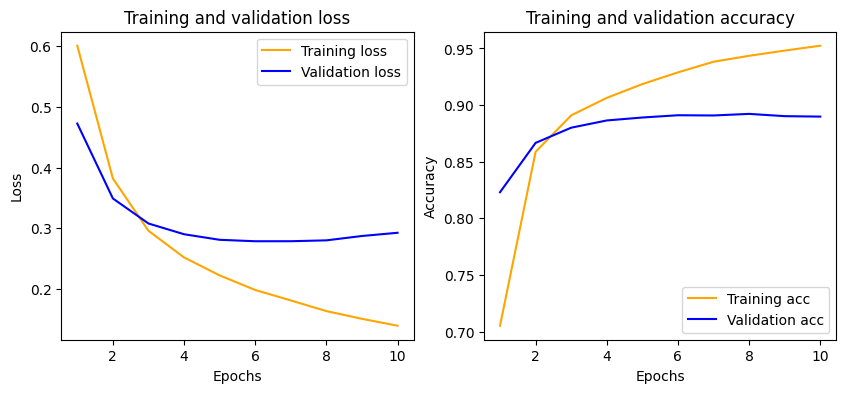

In [42]:
history_dict = history.history
history_dict.keys()

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(epochs, loss, 'orange', label='Training loss')
ax1.plot(epochs, val_loss, 'b', label='Validation loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, acc, 'orange', label='Training acc')
ax2.plot(epochs, val_acc, 'b', label='Validation acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')

plt.show()

# Attempt #2 - LR scheduler with spatial dropout
## Create the Model

In [43]:
embedding_dim = 500

model = tf.keras.Sequential([
    layers.Embedding(max_features, embedding_dim),
    layers.SpatialDropout1D(0.4),  
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, None, 500)         5000000   
                                                                 
 spatial_dropout1d (Spatial  (None, None, 500)         0         
 Dropout1D)                                                      
                                                                 
 global_average_pooling1d_2  (None, 500)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_2 (Dense)             (None, 64)                32064     
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                

## Compile and Train the Model

In [44]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9)
model.compile(loss=losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.5)])

In [45]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
626/626 [==============================] - 21s 33ms/step - loss: 0.5771 - binary_accuracy: 0.7293 - val_loss: 0.4172 - val_binary_accuracy: 0.8480
Epoch 2/10
626/626 [==============================] - 2s 3ms/step - loss: 0.3568 - binary_accuracy: 0.8795 - val_loss: 0.3381 - val_binary_accuracy: 0.8866
Epoch 3/10
626/626 [==============================] - 2s 3ms/step - loss: 0.2911 - binary_accuracy: 0.9088 - val_loss: 0.3152 - val_binary_accuracy: 0.8882
Epoch 4/10
626/626 [==============================] - 2s 3ms/step - loss: 0.2518 - binary_accuracy: 0.9226 - val_loss: 0.3077 - val_binary_accuracy: 0.8900
Epoch 5/10
626/626 [==============================] - 2s 3ms/step - loss: 0.2233 - binary_accuracy: 0.9369 - val_loss: 0.3054 - val_binary_accuracy: 0.8914
Epoch 6/10
626/626 [==============================] - 2s 3ms/step - loss: 0.2046 - binary_accuracy: 0.9428 - val_loss: 0.3061 - val_binary_accuracy: 0.8900
Epoch 7/10
626/626 [==============================] - 2s 3ms/s

## Evaluate the Model

In [46]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 [==============================] - 1s 997us/step - loss: 0.3545 - binary_accuracy: 0.8760
Loss:  0.3545176088809967
Accuracy:  0.876039981842041


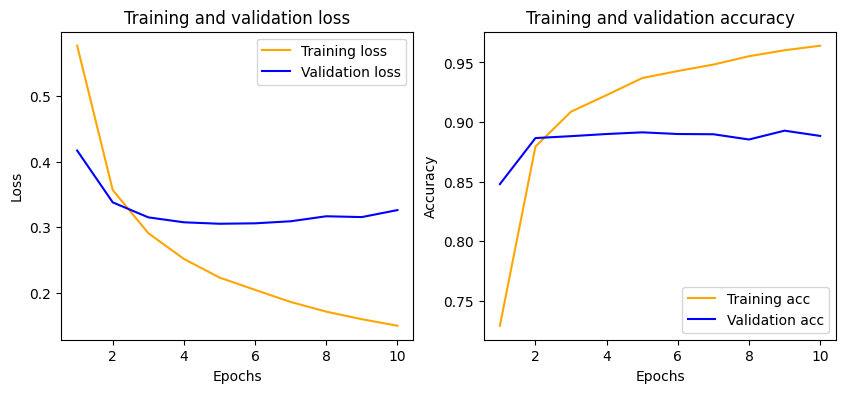

In [47]:
history_dict = history.history
history_dict.keys()

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(epochs, loss, 'orange', label='Training loss')
ax1.plot(epochs, val_loss, 'b', label='Validation loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, acc, 'orange', label='Training acc')
ax2.plot(epochs, val_acc, 'b', label='Validation acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')

plt.show()

# Attempt #3 - LR scheduler and spatial dropout with word embeddings
## Retreive Glove Word Embdedding

In [48]:
path_to_glove_file = "glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

Found 400000 word vectors.


In [49]:
voc = vectorize_layer.get_vocabulary()
num_tokens = len(voc) + 2
embedding_dim = 100
hits = 0
misses = 0
word_index = dict(zip(voc, range(len(voc))))

embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all zeros
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))
embedding_matrix = tf.keras.initializers.Constant(embedding_matrix)   # Needs to be tf.Constant for the model

Converted 9891 words (109 misses)


## Create the Model

In [50]:
embedding_dim = 500
max_features = 10000
sequence_length = 500

model = tf.keras.Sequential([
    layers.Embedding(num_tokens, 100, embeddings_initializer=embedding_matrix, input_length=sequence_length), 
    layers.SpatialDropout1D(0.4),  
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 500, 100)          1000200   
                                                                 
 spatial_dropout1d_1 (Spati  (None, 500, 100)          0         
 alDropout1D)                                                    
                                                                 
 global_average_pooling1d_3  (None, 100)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_4 (Dense)             (None, 64)                6464      
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                

## Compile and Train the Model

In [51]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  
    decay_steps=2000,              
    decay_rate=0.95)               

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)
model.compile(loss=losses.BinaryCrossentropy(),
              optimizer=optimizer,
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.5)])

In [52]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
626/626 [==============================] - 32s 49ms/step - loss: 0.7253 - binary_accuracy: 0.5703 - val_loss: 0.6725 - val_binary_accuracy: 0.6900
Epoch 2/10
626/626 [==============================] - 1s 2ms/step - loss: 0.6386 - binary_accuracy: 0.6982 - val_loss: 0.5639 - val_binary_accuracy: 0.7854
Epoch 3/10
626/626 [==============================] - 1s 2ms/step - loss: 0.5339 - binary_accuracy: 0.7951 - val_loss: 0.4733 - val_binary_accuracy: 0.8400
Epoch 4/10
626/626 [==============================] - 1s 2ms/step - loss: 0.4610 - binary_accuracy: 0.8386 - val_loss: 0.4247 - val_binary_accuracy: 0.8578
Epoch 5/10
626/626 [==============================] - 1s 2ms/step - loss: 0.4140 - binary_accuracy: 0.8597 - val_loss: 0.3912 - val_binary_accuracy: 0.8692
Epoch 6/10
626/626 [==============================] - 1s 2ms/step - loss: 0.3811 - binary_accuracy: 0.8702 - val_loss: 0.3700 - val_binary_accuracy: 0.8744
Epoch 7/10
626/626 [==============================] - 1s 2ms/s

## Evaluate the Model

In [53]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 [==============================] - 1s 876us/step - loss: 0.3298 - binary_accuracy: 0.8834
Loss:  0.3298262059688568
Accuracy:  0.8833600282669067


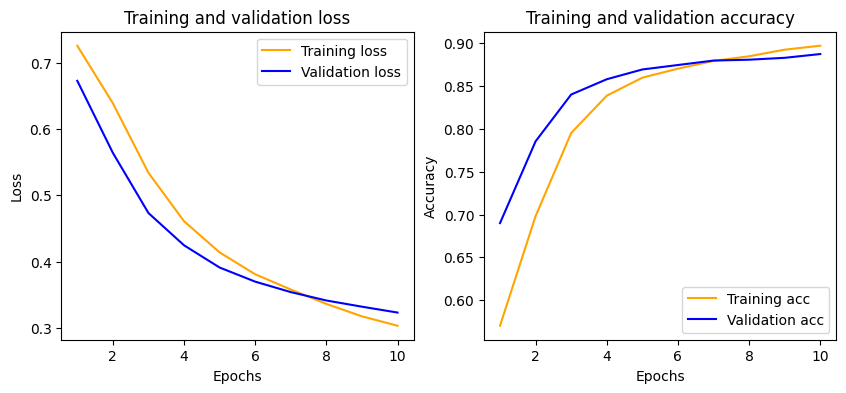

In [54]:
history_dict = history.history
history_dict.keys()

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# "bo" is for "blue dot" - I chose orange line instead
ax1.plot(epochs, loss, 'orange', label='Training loss')
# b is for "solid blue line"
ax1.plot(epochs, val_loss, 'b', label='Validation loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, acc, 'orange', label='Training acc')
ax2.plot(epochs, val_acc, 'b', label='Validation acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')

plt.show()

# Attempt #4 - LR Scheduler, spatial dropout, Glove word embedding, and batch normalization
## Create the Model

In [55]:
embedding_dim = 500
max_features = 10000
sequence_length = 500

model = tf.keras.Sequential([
    layers.Embedding(num_tokens, 100, embeddings_initializer=embedding_matrix, input_length=sequence_length),
    layers.SpatialDropout1D(0.4),
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005)), 
    layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 500, 100)          1000200   
                                                                 
 spatial_dropout1d_2 (Spati  (None, 500, 100)          0         
 alDropout1D)                                                    
                                                                 
 global_average_pooling1d_4  (None, 100)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_6 (Dense)             (None, 128)               12928     
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                      

## Compile and Train the Model

In [56]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  
    decay_steps=2000,              
    decay_rate=0.95)               

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)
model.compile(loss=losses.BinaryCrossentropy(),
              optimizer=optimizer,
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.5)])

In [57]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
626/626 [==============================] - 23s 34ms/step - loss: 0.9170 - binary_accuracy: 0.5183 - val_loss: 0.8553 - val_binary_accuracy: 0.6398
Epoch 2/10
626/626 [==============================] - 2s 3ms/step - loss: 0.8332 - binary_accuracy: 0.5656 - val_loss: 0.7612 - val_binary_accuracy: 0.6986
Epoch 3/10
626/626 [==============================] - 2s 3ms/step - loss: 0.7176 - binary_accuracy: 0.6893 - val_loss: 0.5482 - val_binary_accuracy: 0.8146
Epoch 4/10
626/626 [==============================] - 2s 3ms/step - loss: 0.5613 - binary_accuracy: 0.7955 - val_loss: 0.4498 - val_binary_accuracy: 0.8554
Epoch 5/10
626/626 [==============================] - 2s 3ms/step - loss: 0.4897 - binary_accuracy: 0.8312 - val_loss: 0.4072 - val_binary_accuracy: 0.8684
Epoch 6/10
626/626 [==============================] - 2s 3ms/step - loss: 0.4386 - binary_accuracy: 0.8491 - val_loss: 0.3816 - val_binary_accuracy: 0.8730
Epoch 7/10
626/626 [==============================] - 2s 3ms/s

## Evaluate the Model

In [58]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 [==============================] - 1s 992us/step - loss: 0.3341 - binary_accuracy: 0.8769
Loss:  0.3340873420238495
Accuracy:  0.8768799901008606


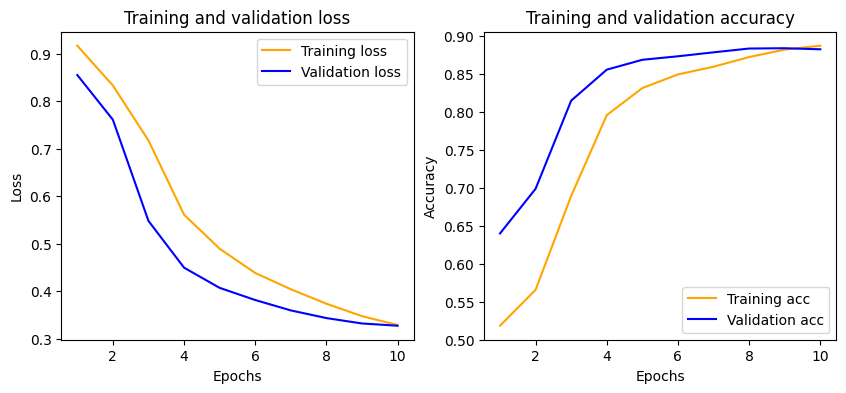

In [59]:
history_dict = history.history
history_dict.keys()

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# "bo" is for "blue dot" - I chose orange line instead
ax1.plot(epochs, loss, 'orange', label='Training loss')
# b is for "solid blue line"
ax1.plot(epochs, val_loss, 'b', label='Validation loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, acc, 'orange', label='Training acc')
ax2.plot(epochs, val_acc, 'b', label='Validation acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')

plt.show()

# Attempt #5 - L2 Regularization with Glove Word Embedding Initialization

## Retreive Glove Word Embedding

In [60]:
# !wget https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
# !unzip -q glove.6B.zip

In [61]:
path_to_glove_file = "glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

Found 400000 word vectors.


In [62]:
voc = vectorize_layer.get_vocabulary()
num_tokens = len(voc) + 2
embedding_dim = 100
hits = 0
misses = 0
word_index = dict(zip(voc, range(len(voc))))

# Prepare embedding matrix
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all zeros
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))
embedding_matrix = tf.keras.initializers.Constant(embedding_matrix)   # Needs to be tf.Constant for the model

Converted 9891 words (109 misses)


## Create the Model

In [63]:
embedding_dim = 500
max_features = 10000
sequence_length = 500

model = tf.keras.Sequential([
  layers.Embedding(num_tokens, 100, embeddings_initializer=embedding_matrix, input_length=sequence_length),          # Initialize with embedding matrix, learn embedding vectors during training, must use emedding dim =100 to match glove
  layers.GlobalAveragePooling1D(),
  layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.02)),  
  layers.Dense(1, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(0.01))])

model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_5 (Embedding)     (None, 500, 100)          1000200   
                                                                 
 global_average_pooling1d_5  (None, 100)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_10 (Dense)            (None, 64)                6464      
                                                                 
 dense_11 (Dense)            (None, 1)                 65        
                                                                 
Total params: 1006729 (3.84 MB)
Trainable params: 1006729 (3.84 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Compile and Train the Model

In [64]:
model.compile(loss=losses.BinaryCrossentropy(),
              optimizer='adam',
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.5)])

In [65]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
626/626 [==============================] - 21s 33ms/step - loss: 0.8467 - binary_accuracy: 0.5528 - val_loss: 0.6938 - val_binary_accuracy: 0.5874
Epoch 2/10
626/626 [==============================] - 1s 2ms/step - loss: 0.6877 - binary_accuracy: 0.6402 - val_loss: 0.6648 - val_binary_accuracy: 0.7340
Epoch 3/10
626/626 [==============================] - 1s 2ms/step - loss: 0.6126 - binary_accuracy: 0.7865 - val_loss: 0.5778 - val_binary_accuracy: 0.8354
Epoch 4/10
626/626 [==============================] - 1s 2ms/step - loss: 0.5458 - binary_accuracy: 0.8519 - val_loss: 0.5426 - val_binary_accuracy: 0.8546
Epoch 5/10
626/626 [==============================] - 1s 2ms/step - loss: 0.5142 - binary_accuracy: 0.8718 - val_loss: 0.5236 - val_binary_accuracy: 0.8648
Epoch 6/10
626/626 [==============================] - 1s 2ms/step - loss: 0.4937 - binary_accuracy: 0.8808 - val_loss: 0.5099 - val_binary_accuracy: 0.8688
Epoch 7/10
626/626 [==============================] - 1s 2ms/s

## Evaluate the Model

In [66]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 [==============================] - 1s 943us/step - loss: 0.4837 - binary_accuracy: 0.8770
Loss:  0.4837097227573395
Accuracy:  0.8769999742507935


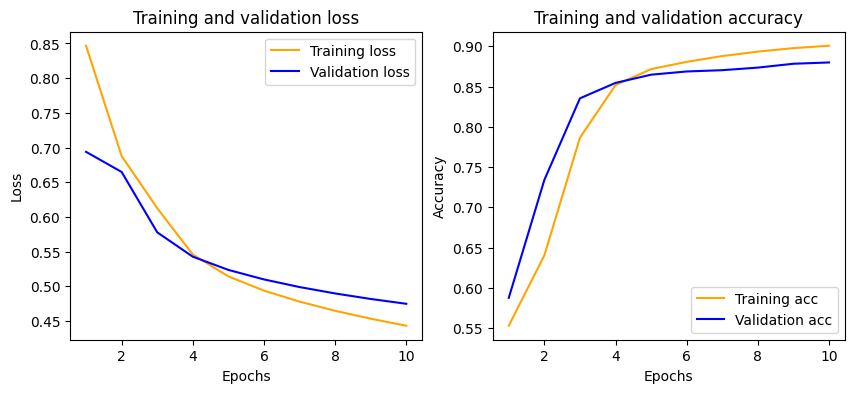

In [67]:
history_dict = history.history
history_dict.keys()

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(epochs, loss, 'orange', label='Training loss')
ax1.plot(epochs, val_loss, 'b', label='Validation loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, acc, 'orange', label='Training acc')
ax2.plot(epochs, val_acc, 'b', label='Validation acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')

plt.show()

# Attempt #6 - LSTM
## Create the Model

In [71]:
# Based on Module 7 Tutorial
np.random.seed(42)
tf.random.set_seed(42)

embedding_dim = 250

model = keras.models.Sequential([
    keras.layers.Embedding(max_features, 64),
    keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True, dropout=0.3)),
    keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True, dropout=0.3)),
    keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True)),
    keras.layers.Bidirectional(keras.layers.LSTM(64)),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    #keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile Train the Model

In [72]:
model.compile(loss=losses.BinaryCrossentropy(),
              optimizer='adam',
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.5)])

In [73]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 78s 113ms/step - binary_accuracy: 0.5292 - loss: 0.9117 - val_binary_accuracy: 0.5125 - val_loss: 0.6919
Epoch 2/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - binary_accuracy: 0.5114 - loss: 0.6925 - val_binary_accuracy: 0.5090 - val_loss: 0.6920
Epoch 3/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - binary_accuracy: 0.5093 - loss: 0.6907 - val_binary_accuracy: 0.5089 - val_loss: 0.6947
Epoch 4/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - binary_accuracy: 0.5082 - loss: 0.6938 - val_binary_accuracy: 0.5065 - val_loss: 0.6933
Epoch 5/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - binary_accuracy: 0.5062 - loss: 0.6931 - val_binary_accuracy: 0.5052 - val_loss: 0.6932
Epoch 6/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - binary_accuracy: 0.5050 - loss: 0.6931 - val_binary_accuracy: 0.5041 - val_loss: 0.6932
Epoch 7/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - binary_accuracy: 0.5040 - loss: 0.6931 - val_binary_accuracy: 0.5033 - va

## Evaluate the Model

In [74]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - binary_accuracy: 0.5017 - loss: 0.6931
Loss:  0.6931560039520264
Accuracy:  0.5016794204711914


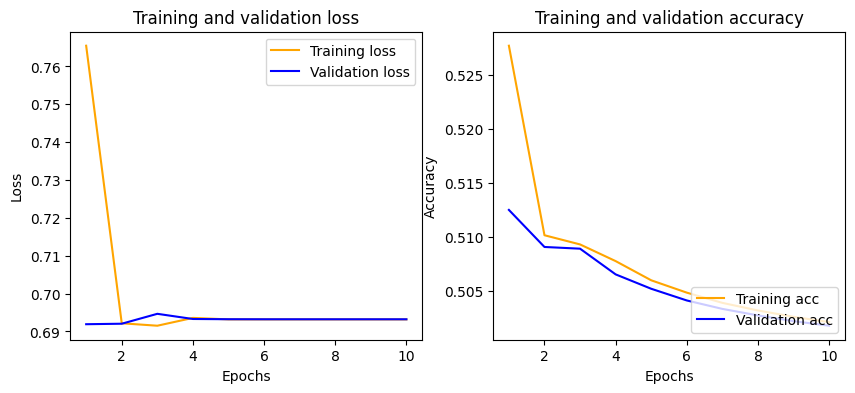

In [75]:
history_dict = history.history
history_dict.keys()

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(epochs, loss, 'orange', label='Training loss')
ax1.plot(epochs, val_loss, 'b', label='Validation loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, acc, 'orange', label='Training acc')
ax2.plot(epochs, val_acc, 'b', label='Validation acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')

plt.show()

# Attempt #7 - LSTM with Glove Word Embedding

In [69]:
path_to_glove_file = "glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

Found 400000 word vectors.


In [70]:
voc = vectorize_layer.get_vocabulary()
num_tokens = len(voc) + 2
embedding_dim = 100
hits = 0
misses = 0
word_index = dict(zip(voc, range(len(voc))))

embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all zeros
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))

Converted 9891 words (109 misses)


## Create the Model

In [76]:

model = keras.models.Sequential([
    keras.layers.Embedding(num_tokens, 100, embeddings_initializer=embedding_matrix, input_length=sequence_length),          # Initialize with embedding matrix and Learn embedding vectors during training, must use emedding dim =100 to match glove
    keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True, dropout=0.3)),
    keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True, dropout=0.3)),
    keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True)),
    keras.layers.Bidirectional(keras.layers.LSTM(64)),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    #keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

/home/uwa6xv/.local/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile and Train the Model

In [77]:
model.compile(loss=losses.BinaryCrossentropy(),
              optimizer='adam',
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.5)])

In [78]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 77s 114ms/step - binary_accuracy: 0.5379 - loss: 0.9028 - val_binary_accuracy: 0.6390 - val_loss: 0.5258
Epoch 2/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - binary_accuracy: 0.6654 - loss: 0.5311 - val_binary_accuracy: 0.7183 - val_loss: 0.3876
Epoch 3/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - binary_accuracy: 0.7353 - loss: 0.3754 - val_binary_accuracy: 0.7676 - val_loss: 0.3989
Epoch 4/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - binary_accuracy: 0.7766 - loss: 0.2952 - val_binary_accuracy: 0.7975 - val_loss: 0.3075
Epoch 5/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 70s 113ms/step - binary_accuracy: 0.8044 - loss: 0.2486 - val_binary_accuracy: 0.8195 - val_loss: 0.2968
Epoch 6/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - binary_accuracy: 0.8244 - loss: 0.2220 - val_binary_accuracy: 0.8356 - val_loss: 0.2904
Epoch 7/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 70s 113ms/step - binary_accuracy: 0.8390 - loss: 0.2218 - val_binary_accuracy: 0.8473 - va

## Evaluate the Model

In [79]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - binary_accuracy: 0.8723 - loss: 0.3705
Loss:  0.3641062378883362
Accuracy:  0.8724102973937988


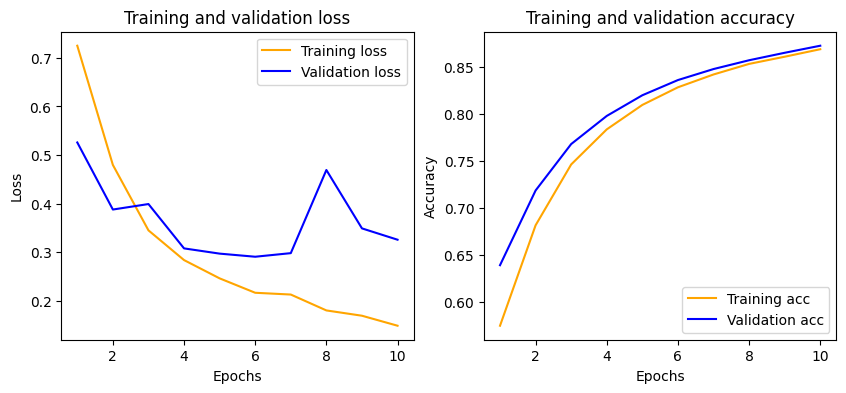

In [80]:
history_dict = history.history
history_dict.keys()

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(epochs, loss, 'orange', label='Training loss')
ax1.plot(epochs, val_loss, 'b', label='Validation loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, acc, 'orange', label='Training acc')
ax2.plot(epochs, val_acc, 'b', label='Validation acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')

plt.show()

# Attempt #8 - Transformer

## Create and Train the Model

In [81]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        # Multi-head self-attention
        attn_output = self.att(inputs, inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        # Feed-forward network
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class TransformerClassifier(keras.Model):
    def __init__(self, max_features, embedding_dim, num_heads, ff_dim, sequence_length):
        super(TransformerClassifier, self).__init__()

        self.embedding = layers.Embedding(input_dim=max_features, output_dim=embedding_dim)
        self.positional_encoding = layers.Embedding(input_dim=sequence_length, output_dim=embedding_dim)
        self.transformer_block = TransformerBlock(embedding_dim, num_heads, ff_dim)
        self.global_avg_pooling = layers.GlobalAveragePooling1D()
        self.dropout = layers.Dropout(0.4)
        self.out = layers.Dense(1, activation='sigmoid')

    def call(self, inputs, training=False):
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        positions = tf.expand_dims(positions, 0)  
        embedded_tokens = self.embedding(inputs)
        embedded_positions = self.positional_encoding(positions)
        x = embedded_tokens + embedded_positions
        x = self.transformer_block(x, training=training)
        x = self.global_avg_pooling(x)
        x = self.dropout(x, training=training)
        return self.out(x)

embedding_dim = 500
num_heads = 4
ff_dim = 128
max_features = 10000
sequence_length = 500

# Initialize and compile the model
model = TransformerClassifier(max_features, embedding_dim, num_heads, ff_dim, sequence_length)

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  
    decay_steps=2000,              
    decay_rate=0.95)               

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)
model.compile(loss=losses.BinaryCrossentropy(),
              optimizer=optimizer,
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.5)])


model.build(input_shape=(None, sequence_length))
model.summary()
# Train the Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Model: "transformer_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_6 (Embedding)     multiple                  5000000   
                                                                 
 embedding_7 (Embedding)     multiple                  250000    
                                                                 
 transformer_block (Transfo  multiple                  4137128   
 rmerBlock)                                                      
                                                                 
 global_average_pooling1d_6  multiple                  0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dropout_10 (Dropout)        multiple                  0         
                                                                 
 dense_14 (Dense)            multiple       

## Evaluate the Model

In [82]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 [==============================] - 11s 14ms/step - loss: 1.0113 - binary_accuracy: 0.8377
Loss:  1.0113389492034912
Accuracy:  0.8377199769020081


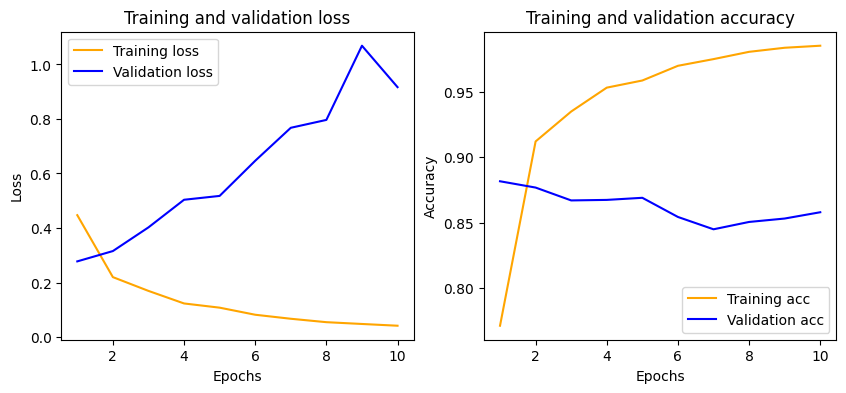

In [83]:
history_dict = history.history
history_dict.keys()

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(epochs, loss, 'orange', label='Training loss')
ax1.plot(epochs, val_loss, 'b', label='Validation loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, acc, 'orange', label='Training acc')
ax2.plot(epochs, val_acc, 'b', label='Validation acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')

plt.show()

# Attempt #9 - BERT
## Preprocess the data 
We need to remove HTML, but do not need vectorization. 

In [6]:
# def custom_standardization(input_data):
#     lowercase = tf.strings.lower(input_data)
#     #stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
#     stripped_html = tf.strings.regex_replace(lowercase, '<.*?>', ' ')                                    #Removes any HTML tag
#     cleaned_text = tf.strings.regex_replace(stripped_html,'[%s]' % re.escape(string.punctuation), '')    #Removes punctuation
#     cleaned_text = tf.strings.regex_replace(cleaned_text, '\\\\[ntr\"\'\\\\]', ' ')                      #Removes escape characters - newline, tab, return, ", ', backslash
#     return cleaned_text
def preprocess_text(input_text, label):
    cleaned_text = custom_standardization(input_text)    
    return cleaned_text, label
train_text = raw_train_ds.map(preprocess_text)
val_text = raw_val_ds.map(preprocess_text)
test_text = raw_test_ds.map(preprocess_text)

## Create the Model

In [7]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers, models, optimizers, losses, metrics, regularizers
import tensorflow_text as text  
import os
keras = tf.keras

bert_preprocess = hub.KerasLayer('https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3', name='bert_preprocess')
bert_encoder = hub.KerasLayer('https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4', trainable=True, name='bert_encoder')

def build_bert_model():
    text_input = keras.Input(shape=(), dtype=tf.string, name='text')  
    preprocessed_text = bert_preprocess(text_input)
    outputs = bert_encoder(preprocessed_text)
    
    # Freeze all BERT layers except the last 30
    for layer in bert_encoder.trainable_variables[:-35]:
        layer._trainable = False
        
    pooled_output = outputs['pooled_output']
    x = layers.BatchNormalization()(pooled_output)
    x = layers.Dropout(0.4)(x)         
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x) 
    output = layers.Dense(1, activation='sigmoid')(x)  
    
    model = keras.Model(inputs=text_input, outputs=output)
    lr_schedule=tf.keras.optimizers.schedules.CosineDecayRestarts(initial_learning_rate=0.00002, first_decay_steps=5000, t_mul=2.0, m_mul=0.8, alpha=0.000001)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001, clipnorm=0.5),
                  loss=keras.losses.BinaryCrossentropy(),
                  metrics=[keras.metrics.BinaryAccuracy()])
    return model

bert_model = build_bert_model()
bert_model.summary()

AUTOTUNE = tf.data.AUTOTUNE
train_text = train_text.cache().prefetch(buffer_size=AUTOTUNE)
val_text = val_text.cache().prefetch(buffer_size=AUTOTUNE)
test_text = test_text.cache().prefetch(buffer_size=AUTOTUNE)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 bert_preprocess (KerasLaye  {'input_mask': (None, 128)   0         ['text[0][0]']                
 r)                          , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                              

## Train the Model

In [8]:
history = bert_model.fit(train_text, 
                         validation_data=val_text, 
                         epochs=20)

Epoch 1/20


I0000 00:00:1742609250.640284  101522 service.cc:148] XLA service 0x7fabf7240eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742609250.640322  101522 service.cc:156]   StreamExecutor device (0): Tesla V100-SXM2-32GB, Compute Capability 7.0
2025-03-21 22:07:30.650134: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742609250.673393  101522 cuda_dnn.cc:529] Loaded cuDNN version 90501
I0000 00:00:1742609250.748390  101522 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


626/626 [==============================] - 128s 170ms/step - loss: 2.7215 - binary_accuracy: 0.7282 - val_loss: 2.4254 - val_binary_accuracy: 0.8484
Epoch 2/20
626/626 [==============================] - 105s 168ms/step - loss: 2.3808 - binary_accuracy: 0.8302 - val_loss: 2.2346 - val_binary_accuracy: 0.8572
Epoch 3/20
626/626 [==============================] - 106s 169ms/step - loss: 2.1579 - binary_accuracy: 0.8489 - val_loss: 2.0431 - val_binary_accuracy: 0.8594
Epoch 4/20
626/626 [==============================] - 105s 168ms/step - loss: 1.9514 - binary_accuracy: 0.8582 - val_loss: 1.8658 - val_binary_accuracy: 0.8612
Epoch 5/20
626/626 [==============================] - 105s 168ms/step - loss: 1.7591 - binary_accuracy: 0.8654 - val_loss: 1.6894 - val_binary_accuracy: 0.8636
Epoch 6/20
626/626 [==============================] - 105s 169ms/step - loss: 1.5884 - binary_accuracy: 0.8770 - val_loss: 1.5351 - val_binary_accuracy: 0.8734
Epoch 7/20
626/626 [==============================]

## Evaluate the Model

In [9]:
loss, accuracy = bert_model.evaluate(test_text)
print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 [==============================] - 82s 105ms/step - loss: 0.7413 - binary_accuracy: 0.8762
Loss:  0.7412745356559753
Accuracy:  0.8761600255966187


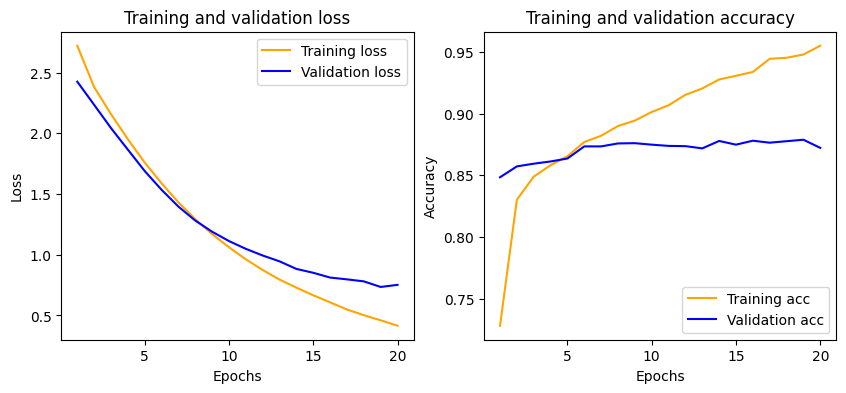

In [10]:
history_dict = history.history
history_dict.keys()

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(epochs, loss, 'orange', label='Training loss')
ax1.plot(epochs, val_loss, 'b', label='Validation loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, acc, 'orange', label='Training acc')
ax2.plot(epochs, val_acc, 'b', label='Validation acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')

plt.show()

# Exercise: multi-class classification on Stack Overflow questions

This tutorial showed how to train a binary classifier from scratch on the IMDB dataset. As an exercise, you can modify this notebook to train a multi-class classifier to predict the tag of a programming question on [Stack Overflow](http://stackoverflow.com/).

A [dataset](https://storage.googleapis.com/download.tensorflow.org/data/stack_overflow_16k.tar.gz) has been prepared for you to use containing the body of several thousand programming questions (for example, "How can I sort a dictionary by value in Python?") posted to Stack Overflow. Each of these is labeled with exactly one tag (either Python, CSharp, JavaScript, or Java). Your task is to take a question as input, and predict the appropriate tag, in this case, Python.

The dataset you will work with contains several thousand questions extracted from the much larger public Stack Overflow dataset on [BigQuery](https://console.cloud.google.com/marketplace/details/stack-exchange/stack-overflow), which contains more than 17 million posts.

After downloading the dataset, you will find it has a similar directory structure to the IMDB dataset you worked with previously:

```
train/
...python/
......0.txt
......1.txt
...javascript/
......0.txt
......1.txt
...csharp/
......0.txt
......1.txt
...java/
......0.txt
......1.txt
```

Note: To increase the difficulty of the classification problem, occurrences of the words Python, CSharp, JavaScript, or Java in the programming questions have been replaced with the word *blank* (as many questions contain the language they're about).

To complete this exercise, you should modify this notebook to work with the Stack Overflow dataset by making the following modifications:

1. At the top of your notebook, update the code that downloads the IMDB dataset with code to download the [Stack Overflow dataset](https://storage.googleapis.com/download.tensorflow.org/data/stack_overflow_16k.tar.gz) that has already been prepared. As the Stack Overflow dataset has a similar directory structure, you will not need to make many modifications.

1. Modify the last layer of your model to `Dense(4)`, as there are now four output classes.

1. When compiling the model, change the loss to `tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)`. This is the correct loss function to use for a multi-class classification problem, when the labels for each class are integers (in this case, they can be 0, *1*, *2*, or *3*). In addition, change the metrics to `metrics=['accuracy']`, since this is a multi-class classification problem (`tf.metrics.BinaryAccuracy` is only used for binary classifiers).

1. When plotting accuracy over time, change `binary_accuracy` and `val_binary_accuracy` to `accuracy` and `val_accuracy`, respectively.

1. Once these changes are complete, you will be able to train a multi-class classifier.

# Learning more

This tutorial introduced text classification from scratch. To learn more about the text classification workflow in general, check out the [Text classification guide](https://developers.google.com/machine-learning/guides/text-classification/) from Google Developers.
